In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from examples.seismic import SeismicModel, AcquisitionGeometry
from examples.seismic.acoustic import AcousticWaveSolver, EikonalSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info
from examples.seismic.fk_filter import FKFilter3D
from scipy import ndimage
from tqdm.notebook import tqdm

PATH_MODEL = "../data/South_ForMigr_2.dat"
PATH_DATA = path = "../data/21-20.sgy"
SO = 4
WAVELET = "Ricker"
NBL = 500
NFKL = 100
FS = False
SUBSAMPLING = 10
slic = NBL - NFKL
slices = (slice(None), slice(slic, -slic, SUBSAMPLING), slice(None, -slic, SUBSAMPLING)) if FS else (slice(None), slice(slic, -slic, SUBSAMPLING), slice(slic, -slic, SUBSAMPLING))


dataset = SeismogramDataset(PATH_DATA, "sou", invert_elevs=True)
xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
spacing = (0.025, 0.025)
velmodel = VelocityModel(PATH_MODEL, dx=spacing[0], dz=spacing[1], clip=True, xmin=xmin-3, xmax=xmax+3, zmin=-318)
velmodel.pad_left(4+2)
velmodel.pad_right(8*int(0.5/spacing[0])+2)
velmodel.pad_bottom(10*int(0.5/spacing[0])+2)
velmodel.pad_top(7*int(0.5/spacing[0]))

origin = velmodel.x[0], velmodel.z[0]
vp = velmodel.vp.T

model = SeismicModel(
    vp=vp,
    origin=origin,
    shape=vp.shape,
    spacing=spacing,
    space_order=SO,
    nbl=NBL,
    bcs="damp",
    fs=False,
)
t0 = 0.0
tn = dataset._t_max
f0 = 0.25

nsnaps = 500
vnx = model.vp.data.shape[0]//10 + 1
vnz = model.vp.data.shape[1]//10 + 1

Operator `initdamp` ran in 0.01 s


In [5]:
print((tn//model.critical_dt+2)/500*model.critical_dt)

0.13876766


In [2]:
def snap_fromfile(path, shape, back=False):
    fobj = open(path, "rb")
    snapsObj_f = np.fromfile(fobj, dtype=np.float32)
    snapsObj_f = np.reshape(snapsObj_f, shape)
    if back:
        snapsObj_f = np.copy(snapsObj_f[::-1])
    fobj.close()
    return snapsObj_f

In [42]:
def imaging_condition(snaps_f, snaps_b, src_illum=True):
    # u0 = np.pad(snaps_f, ((1, 1), (0, 0), (0, 0)), mode='constant')
    # udt2 = (u0[2:] - 2*u0[1:-1] + u0[:-2])
    # image = np.sum(udt2*snaps_b, axis=0)
    v = np.pad(snaps_b, ((1, 1), (0, 0), (0, 0)), mode='constant')
    vdt2 = (v[2:] - 2*v[1:-1] + v[:-2])
    image = np.sum(snaps_f*vdt2, axis=0)
    if src_illum:
        image /= np.sum(snaps_f**2, axis=0)
        # image /= np.sum(snaps_f.ravel()**2)
    return image

In [43]:
i = 30
_, sx, sz, rec_x, rec_z = dataset[i]

f0 = 0.3

filename_b = f"../custom_scripts/mex/backward_snaps/{i+1}.bin"
filename_f =  f"../custom_scripts/mex/forward_snaps/{i+1}.bin"

snapsObj_f = snap_fromfile(filename_f, (nsnaps, vnx, vnz))
snapsObj_b = snap_fromfile(filename_b, (nsnaps, vnx, vnz), back=False)
print(snapsObj_f.shape)
print(snapsObj_b.shape)

(500, 264, 365)
(500, 264, 365)


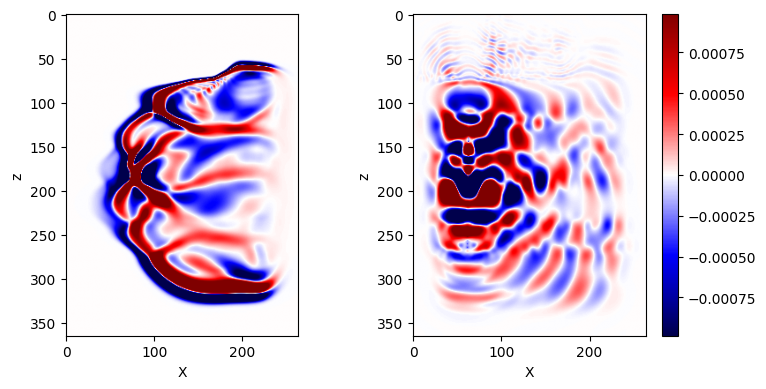

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
qa1 = np.quantile(snapsObj_f, 0.99)
qa2 = np.quantile(snapsObj_b, 0.99)
matrice0 = axs[0].imshow(snapsObj_f[100, :, :].T, vmin=-qa1, vmax=qa1, cmap="seismic")
matrice1 = axs[1].imshow(snapsObj_b[100, :, :].T, vmin=-qa2, vmax=qa2, cmap="seismic")
fig.colorbar(matrice1)

for ax in axs:
    ax.set_xlabel('X')
    ax.set_ylabel('z')

plt.tight_layout()
plt.show()

In [79]:
dt=(tn/nsnaps)/1000
dt

0.000138756

In [80]:
snapsObj_f.T.shape

(365, 264, 500)

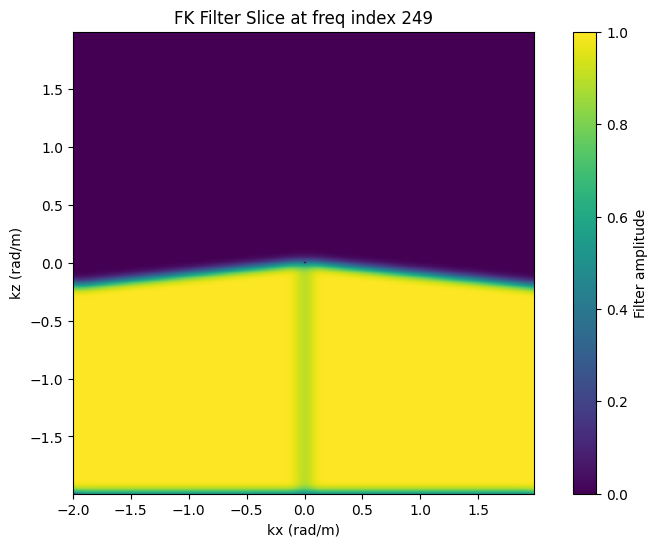

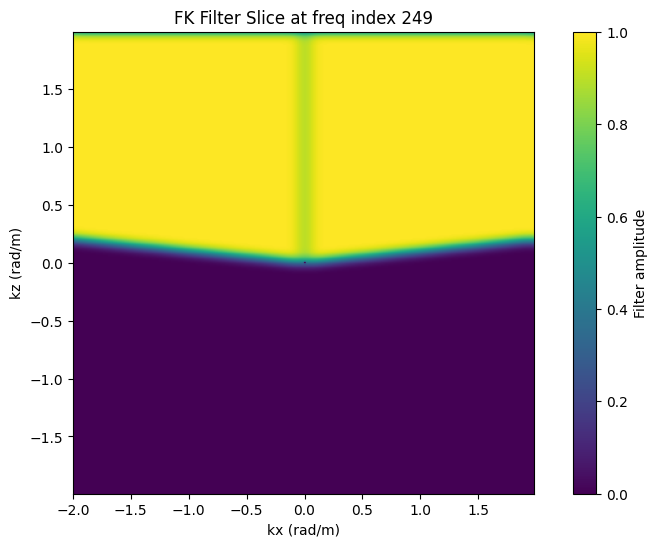

In [45]:
fk_down = FKFilter3D(dx=model.spacing[0]*SUBSAMPLING, dz=model.spacing[1]*SUBSAMPLING,
                dt=(tn/nsnaps)/1000, sigma_x=1, sigma_z=1, min_slope=-1e9, max_slope=-1e-4, gaussian_sigma=0.001, lower_min=0.0, upper_min=0.0)
fk_down._compute_filter(*snapsObj_f.T.shape)
fk_up = FKFilter3D(dx=model.spacing[0]*SUBSAMPLING, dz=model.spacing[1]*SUBSAMPLING,
                dt=(tn/nsnaps)/1000, sigma_x=1, sigma_z=1, min_slope=1e-4, max_slope=1e9, gaussian_sigma=0.001, lower_min=0.0, upper_min=0.0)
fk_up._compute_filter(*snapsObj_f.T.shape)
fk_down.plot_filter_slice(249)
fk_up.plot_filter_slice(249)

In [46]:
snaps_f_up = fk_up(snapsObj_f.T).T
snaps_f_down = fk_down(snapsObj_f.T).T
snaps_b_up = fk_up(snapsObj_b.T).T
snaps_b_down = fk_down(snapsObj_b.T).T
print(snaps_b_up.shape)

(500, 264, 365)


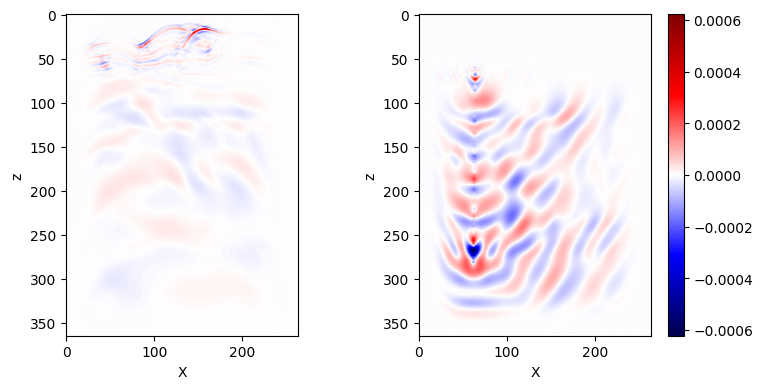

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
qa1 = np.quantile(snaps_f_up, 0.999)
qa2 = np.quantile(snaps_b_up, 0.99)
matrice0 = axs[0].imshow(snaps_f_up[250, :, :].T, vmin=-qa1, vmax=qa1, cmap="seismic")
matrice1 = axs[1].imshow(snaps_b_up[250, :, :].T, vmin=-qa2, vmax=qa2, cmap="seismic")
fig.colorbar(matrice1)

for ax in axs:
    ax.set_xlabel('X')
    ax.set_ylabel('z')

plt.tight_layout()
plt.show()

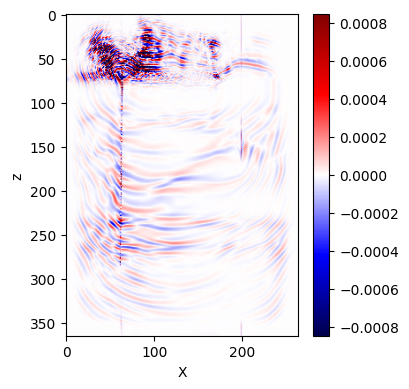

In [48]:
# snaps_b_down
# snaps_b_up
single_image = imaging_condition(snaps_f_down, snaps_b_up, src_illum=True)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
qa = np.quantile(single_image, 0.99)
matrice0 = ax.imshow(ndimage.laplace(single_image).T, vmin=-qa, vmax=qa, cmap="seismic")
fig.colorbar(matrice0)

ax.set_xlabel('X')
ax.set_ylabel('z')


plt.tight_layout()
plt.show()

In [49]:
images_u = np.zeros((len(dataset), *single_image.shape), dtype=np.float32)
images_d = np.zeros((len(dataset), *single_image.shape), dtype=np.float32)
images_u_il = np.zeros((len(dataset), *single_image.shape), dtype=np.float32)
images_d_il = np.zeros((len(dataset), *single_image.shape), dtype=np.float32)
for i in tqdm(range(len(dataset))):
    filename_b = f"../custom_scripts/mex/backward_snaps/{i+1}.bin"
    filename_f =  f"../custom_scripts/mex/forward_snaps/{i+1}.bin"
    snapsObj_f = snap_fromfile(filename_f, (nsnaps, vnx, vnz))
    snapsObj_b = snap_fromfile(filename_b, (nsnaps, vnx, vnz))
    snaps_f_up = fk_up(snapsObj_f.T).T
    snaps_f_down = fk_down(snapsObj_f.T).T
    snaps_b_up = fk_up(snapsObj_b.T).T
    snaps_b_down = fk_down(snapsObj_b.T).T
    images_u[i] = imaging_condition(snaps_f_down, snaps_b_up, src_illum=False)
    images_d[i] = imaging_condition(snaps_f_up, snaps_b_down, src_illum=False)
    images_u_il[i] = imaging_condition(snaps_f_down, snaps_b_up, src_illum=True)
    images_d_il[i] = imaging_condition(snaps_f_up, snaps_b_down, src_illum=True)

  0%|          | 0/59 [00:00<?, ?it/s]

In [56]:
def laplace_gather(images):
    images_f = np.copy(images)
    for i in range(images.shape[0]):
        images_f[i] = ndimage.laplace(images[i])
    return images_f

def diff_gather(images):
    images_f = np.copy(images)
    for i in range(images.shape[0]):
        images_f[i] = np.diff(images[i], prepend=0)
    return images_f

In [62]:
images_u_filt = laplace_gather(images_u)
images_d_filt = laplace_gather(images_d)
images_u_il_filt = laplace_gather(images_u_il)
images_d_il_filt = laplace_gather(images_d_il)
images_u_filt = np.copy(images_u)
images_d_filt = np.copy(images_d)
images_u_il_filt = np.copy(images_u_il)
images_d_il_filt = np.copy(images_d_il)



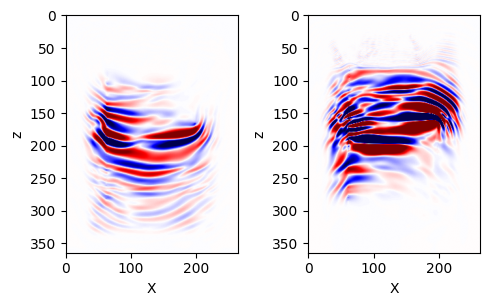

In [63]:
# snaps_b_down
# snaps_b_up
nx = images_u_filt.shape[1]
ns = images_u_filt.shape[0]
fig, axs = plt.subplots(1, 2, figsize=(5, 4))
# qa1 = np.quantile(images_u_filt[:, nx//2, :].T, 0.995)
# qa2 = np.quantile(images_d_filt[:, nx//2, :].T, 0.995)
qa1 = np.quantile(images_u_filt[ns//2, :, :].T, 0.99)
qa2 = np.quantile(images_d_filt[ns//2:, :, :].T, 0.99)

# matrice0 = axs[0].imshow(images_u_filt[:, nx//2, :].T, vmin=-qa, vmax=qa, cmap="seismic", aspect='auto')
# matrice1 = axs[1].imshow(images_d_filt[:, nx//2, :].T, vmin=-qa, vmax=qa, cmap="seismic", aspect='auto')
matrice0 = axs[0].imshow(images_u_filt[ns//2, :, :].T, vmin=-qa1, vmax=qa1, cmap="seismic", aspect='equal')
matrice1 = axs[1].imshow(images_d_filt[ns//2, :, :].T, vmin=-qa2, vmax=qa2, cmap="seismic", aspect='equal')

# fig.colorbar(matrice1)
for ax in axs:
    ax.set_xlabel('X')
    ax.set_ylabel('z')

plt.tight_layout()
plt.show()

In [64]:
def stack_shots(images):
    return np.sum(images, axis=0)

In [77]:
stack_ud = stack_shots(images_u_filt) - 0*stack_shots(images_d_filt)
stack_ud_il = stack_shots(images_u_il_filt) - 0*stack_shots(images_d_il_filt)
stack_ud = stack_shots(images_d_il_filt)

# stack_ud = ndimage.laplace(stack_shots(images_u-images_d))
# stack_ud_il = ndimage.laplace(stack_shots(images_u_il-images_d_il))

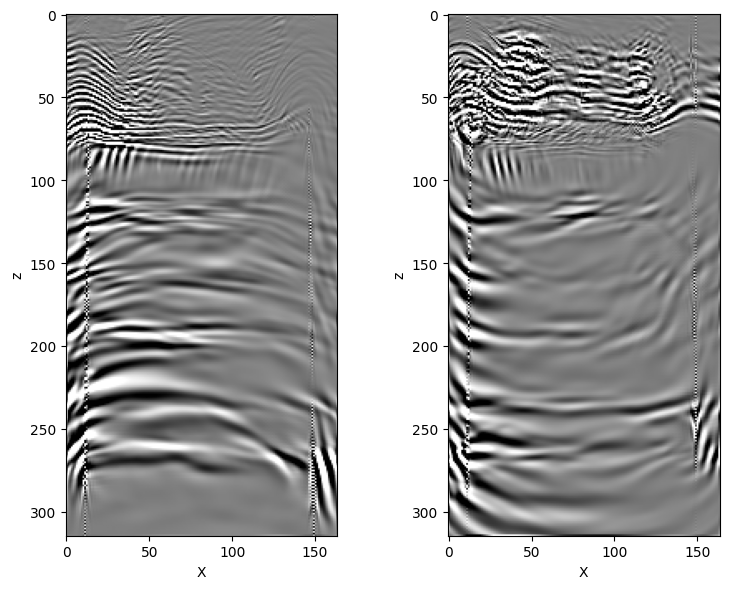

In [78]:
fig, axs = plt.subplots(1, 2, figsize=(8, 6), dpi=100)
qa = np.quantile(ndimage.laplace(stack_ud), 0.97)
matrice0 = axs[0].imshow(ndimage.laplace(stack_ud[50:-50, :-50].T), vmin=-qa, vmax=qa, cmap="gray", aspect='equal')
qa = np.quantile(ndimage.laplace(stack_ud_il), 0.97)
matrice1 = axs[1].imshow(ndimage.laplace(stack_ud_il[50:-50, :-50].T), vmin=-qa, vmax=qa, cmap="gray", aspect='equal')

# fig.colorbar(matrice1)
for ax in axs:
    ax.set_xlabel('X')
    ax.set_ylabel('z')

plt.tight_layout()
plt.show()